In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
import pickle
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from itertools import combinations

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12
})
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [2]:
df = pd.read_csv(r'C:\Users\Aya\Desktop\Data Mining Project (2)\Data Mining Project\amazon_dirty_data (1).csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (1515, 16)
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1515 non-null   object
 1   product_name         1515 non-null   object
 2   category             1515 non-null   object
 3   discounted_price     1346 non-null   object
 4   actual_price         1515 non-null   object
 5   discount_percentage  1515 non-null   object
 6   rating               1346 non-null   object
 7   rating_count         1318 non-null   object
 8   about_product        1515 non-null   object
 9   user_id              1515 non-null   object
 10  user_name            1515 non-null   object
 11  review_id            1515 non-null   object
 12  review_title         1515 non-null   object
 13  review_content       1515 non-null   object
 14  img_link             1515 non-null   object
 15  product_link         1515 non-null   object
dtypes: obj

In [4]:
print(df.isnull().sum())

product_id               0
product_name             0
category                 0
discounted_price       169
actual_price             0
discount_percentage      0
rating                 169
rating_count           197
about_product            0
user_id                  0
user_name                0
review_id                0
review_title             0
review_content           0
img_link                 0
product_link             0
dtype: int64


In [5]:
df_clean = df.copy()

In [6]:
df_clean.dropna(subset=['discounted_price', 'actual_price', 'rating'], inplace=True)

In [7]:
df_clean['discounted_price'] = df_clean['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df_clean['actual_price']     = df_clean['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df_clean['discount_pct']     = df_clean['discount_percentage'].str.replace('%', '', regex=False).astype(float)
df_clean['rating_count']     = pd.to_numeric(df_clean['rating_count'].str.replace(',', '', regex=False), errors='coerce').fillna(0).astype(int)

In [8]:
df_clean['main_category'] = df_clean['category'].str.split('|').str[0]
df_clean['sub_category']  = df_clean['category'].str.split('|').str[-1]
df_clean = df_clean[df_clean['main_category'] != 'unknown_category'].reset_index(drop=True)
df_clean['brand'] = df_clean['product_name'].str.split().str[0].str.lower().str.strip()
df_clean.drop_duplicates(subset='product_id', keep='first', inplace=True)
df_clean[['product_id','product_name','main_category','sub_category','brand',
          'discounted_price','actual_price','discount_pct','rating','rating_count']].head()

,product_id,product_name,main_category,sub_category,brand,discounted_price,actual_price,discount_pct,rating,rating_count
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,USBCables,wayona,399.0,1099.0,64.0,4.2,24269
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,USBCables,ambrane,199.0,349.0,43.0,4.0,43994
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,USBCables,sounce,199.0,1899.0,90.0,3.9,7928
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,USBCables,boat,329.0,699.0,53.0,4.2,94363
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,USBCables,portronics,154.0,399.0,61.0,4.2,16905


In [9]:
transactions = df_clean['category'].str.split('|').tolist()

print(f'Total transactions: {len(transactions)}')
print(f'Sample transaction: {transactions[0]}')

te = TransactionEncoder()
te_arr = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_arr, columns=te.columns_)

print(f'\nTransaction matrix shape: {basket_df.shape}')
basket_df.head()

Total transactions: 1180
Sample transaction: ['Computers&Accessories', 'Accessories&Peripherals', 'Cables&Accessories', 'Cables', 'USBCables']

Transaction matrix shape: (1180, 308)


,3DGlasses,AVReceivers&Amplifiers,Accessories,Accessories&Peripherals,Adapters,Adapters&Multi-Outlets,AirFryers,AirPurifiers,AirPurifiers&Ionizers,Arts&Crafts,...,WaterPurifiers&Accessories,WearableTechnology,Webcams,Webcams&VoIPEquipment,WeighingScales,Wet-DryVacuums,WetGrinders,WireboundNotebooks,WirelessUSBAdapters,WoodenPencils
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Apriori Algorithm

In [10]:
freq_apriori = apriori(basket_df, min_support=0.05, use_colnames=True)
freq_apriori['length'] = freq_apriori['itemsets'].apply(len)
freq_apriori_sorted = freq_apriori.sort_values('support', ascending=False)

print(f'Frequent itemsets found: {len(freq_apriori)}')
print(f'  - 1-itemsets: {len(freq_apriori[freq_apriori.length==1])}')
print(f'  - 2-itemsets: {len(freq_apriori[freq_apriori.length==2])}')
print(f'  - 3-itemsets: {len(freq_apriori[freq_apriori.length==3])}')
freq_apriori_sorted.head(10)

Frequent itemsets found: 61
  - 1-itemsets: 16
  - 2-itemsets: 24
  - 3-itemsets: 15


,support,itemsets,length
5,0.364407,(Electronics),1
7,0.322881,(Home&Kitchen),1
4,0.283898,(Computers&Accessories),1
1,0.238136,(Accessories&Peripherals),1
20,0.238136,"(Computers&Accessories, Accessories&Peripherals)",2
9,0.225424,(Kitchen&HomeAppliances),1
33,0.225424,"(Home&Kitchen, Kitchen&HomeAppliances)",2
2,0.151695,(Cables),1
19,0.131356,"(Cables&Accessories, Accessories&Peripherals)",2
25,0.131356,"(Cables&Accessories, Computers&Accessories)",2


In [11]:
rules_apriori = association_rules(freq_apriori, metric='lift', min_threshold=1.2)
rules_apriori = rules_apriori.sort_values('lift', ascending=False)

print(f'Association rules found: {len(rules_apriori)}')
rules_apriori[['antecedents','consequents','support','confidence','lift']].head(10)

Association rules found: 238


,antecedents,consequents,support,confidence,lift
45,(Mobiles&Accessories),(MobileAccessories),0.053390,0.496063,9.291339
116,"(Mobiles&Accessories, Electronics)",(MobileAccessories),0.053390,0.496063,9.291339
119,(Mobiles&Accessories),"(MobileAccessories, Electronics)",0.053390,0.496063,9.291339
46,(Smartphones&BasicMobiles),(Mobiles&Accessories),0.054237,1.000000,9.291339
47,(Mobiles&Accessories),(Smartphones&BasicMobiles),0.054237,0.503937,9.291339
44,(MobileAccessories),(Mobiles&Accessories),0.053390,1.000000,9.291339
124,(Smartphones&BasicMobiles),"(Mobiles&Accessories, Electronics)",0.054237,1.000000,9.291339
120,"(Smartphones&BasicMobiles, Electronics)",(Mobiles&Accessories),0.054237,1.000000,9.291339
121,"(Mobiles&Accessories, Electronics)",(Smartphones&BasicMobiles),0.054237,0.503937,9.291339
125,(Mobiles&Accessories),"(Smartphones&BasicMobiles, Electronics)",0.054237,0.503937,9.291339


### FP-Growth Algorithm

In [12]:
freq_fpgrowth = fpgrowth(basket_df, min_support=0.05, use_colnames=True)
freq_fpgrowth['length'] = freq_fpgrowth['itemsets'].apply(len)

rules_fp = association_rules(freq_fpgrowth, metric='lift', min_threshold=1.2)
rules_fp = rules_fp.sort_values('lift', ascending=False)

print(f'FP-Growth frequent itemsets: {len(freq_fpgrowth)}')
print(f'FP-Growth rules: {len(rules_fp)}')

pickle.dump(rules_fp, open("rules_fp.pkl", "wb"))

print(f'\nApriori vs FP-Growth itemsets: {len(freq_apriori)} vs {len(freq_fpgrowth)}')
rules_fp[['antecedents','consequents','support','confidence','lift']].head(10)

FP-Growth frequent itemsets: 61
FP-Growth rules: 238

Apriori vs FP-Growth itemsets: 61 vs 61


,antecedents,consequents,support,confidence,lift
195,(Mobiles&Accessories),(MobileAccessories),0.053390,0.496063,9.291339
201,(Mobiles&Accessories),"(MobileAccessories, Electronics)",0.053390,0.496063,9.291339
199,"(Electronics, Mobiles&Accessories)",(MobileAccessories),0.053390,0.496063,9.291339
210,"(Smartphones&BasicMobiles, Electronics)",(Mobiles&Accessories),0.054237,1.000000,9.291339
200,"(MobileAccessories, Electronics)",(Mobiles&Accessories),0.053390,1.000000,9.291339
209,"(Electronics, Mobiles&Accessories)",(Smartphones&BasicMobiles),0.054237,0.503937,9.291339
194,(MobileAccessories),(Mobiles&Accessories),0.053390,1.000000,9.291339
204,(Smartphones&BasicMobiles),(Mobiles&Accessories),0.054237,1.000000,9.291339
212,(Smartphones&BasicMobiles),"(Electronics, Mobiles&Accessories)",0.054237,1.000000,9.291339
205,(Mobiles&Accessories),(Smartphones&BasicMobiles),0.054237,0.503937,9.291339


In [13]:
df_graph = df_clean.drop_duplicates(subset='product_id', keep='first').copy()
print(f'Products after dedup: {len(df_graph)} (was {len(df_clean)})')

df_users = df_graph[['product_id', 'user_id']].copy()
df_users['user_id'] = df_users['user_id'].str.split(',')
df_users = df_users.explode('user_id')
df_users['user_id'] = df_users['user_id'].str.strip()

G = nx.Graph()
G.add_nodes_from(df_graph['product_id'].tolist())

for uid, group in df_users.groupby('user_id'):
    prods = group['product_id'].unique().tolist()  
    if len(prods) > 1:
        for a, b in combinations(prods, 2):
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)

print(f'Graph nodes (products): {G.number_of_nodes()}')
print(f'Graph edges (co-reviews): {G.number_of_edges()}')
print(f'Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}')
print(f'Graph density: {nx.density(G):.4f}')


Products after dedup: 1180 (was 1180)


Graph nodes (products): 1180
Graph edges (co-reviews): 512
Average degree: 0.87
Graph density: 0.0007


### PageRank

In [14]:
pagerank_scores = nx.pagerank(G, weight='weight', alpha=0.85)
pagerank_df = pd.DataFrame(list(pagerank_scores.items()), columns=['product_id', 'pagerank_score'])
pagerank_df = pagerank_df.sort_values('pagerank_score', ascending=False).reset_index(drop=True)

product_info = df_clean[['product_id','product_name','brand','main_category','sub_category',
                          'discounted_price','actual_price','discount_pct','rating','rating_count']].drop_duplicates('product_id')
pagerank_df = pagerank_df.merge(product_info, on='product_id', how='left')

print('=== Top 10 Products by PageRank ===')
pagerank_df[['product_name','brand','main_category','discounted_price','rating','pagerank_score']].head(10)

=== Top 10 Products by PageRank ===


,product_name,brand,main_category,discounted_price,rating,pagerank_score
0,Ambrane 60W / 3A Fast Charging Output Cable wi...,ambrane,Computers&Accessories,179.0,4.0,0.003877
1,Ambrane 60W / 3A Fast Charging Output Cable wi...,ambrane,Computers&Accessories,149.0,4.0,0.003877
2,TIZUM High Speed HDMI Cable Aura -Gold Plated-...,tizum,Electronics,379.0,4.2,0.003663
3,Tizum High Speed HDMI Cable with Ethernet | Su...,tizum,Electronics,199.0,4.2,0.003663
4,"Ambrane 10000mAh Slim Power Bank, 20W Fast Cha...",ambrane,Electronics,999.0,4.0,0.003382
5,"Ambrane 10000mAh Slim Power Bank, 20W Fast Cha...",ambrane,Electronics,999.0,4.0,0.003382
6,"Dell MS116 1000Dpi USB Wired Optical Mouse, Le...",dell,Computers&Accessories,299.0,4.5,0.003267
7,boAt Bassheads 242 in Ear Wired Earphones with...,boat,Electronics,455.0,4.1,0.002986
8,boAt Bassheads 242 in Ear Wired Earphones with...,boat,Electronics,599.0,4.1,0.002986
9,Noise ColorFit Pulse Grand Smart Watch with 1....,noise,Electronics,1999.0,4.0,0.002964


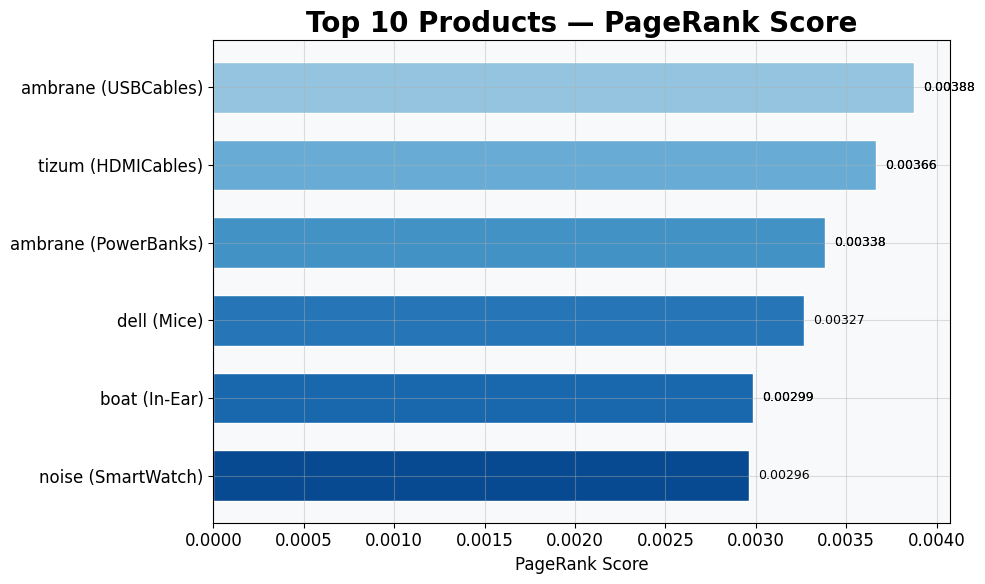

In [15]:
plt.figure(figsize=(10, 6))

top10_pr = pagerank_df.head(10).copy()
top10_pr['short_name'] = top10_pr['brand'] + ' (' + top10_pr['sub_category'].str[:10] + ')'

colors_pr = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10_pr)))

bars = plt.barh(
    top10_pr['short_name'][::-1],
    top10_pr['pagerank_score'][::-1],
    color=colors_pr[::-1],
    edgecolor='white',
    height=0.65
)

plt.title('Top 10 Products — PageRank Score', fontsize=20, fontweight='bold')
plt.xlabel('PageRank Score')

for bar in bars:
    w = bar.get_width()
    plt.text(
        w + 0.00005,
        bar.get_y() + bar.get_height()/2,
        f'{w:.5f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

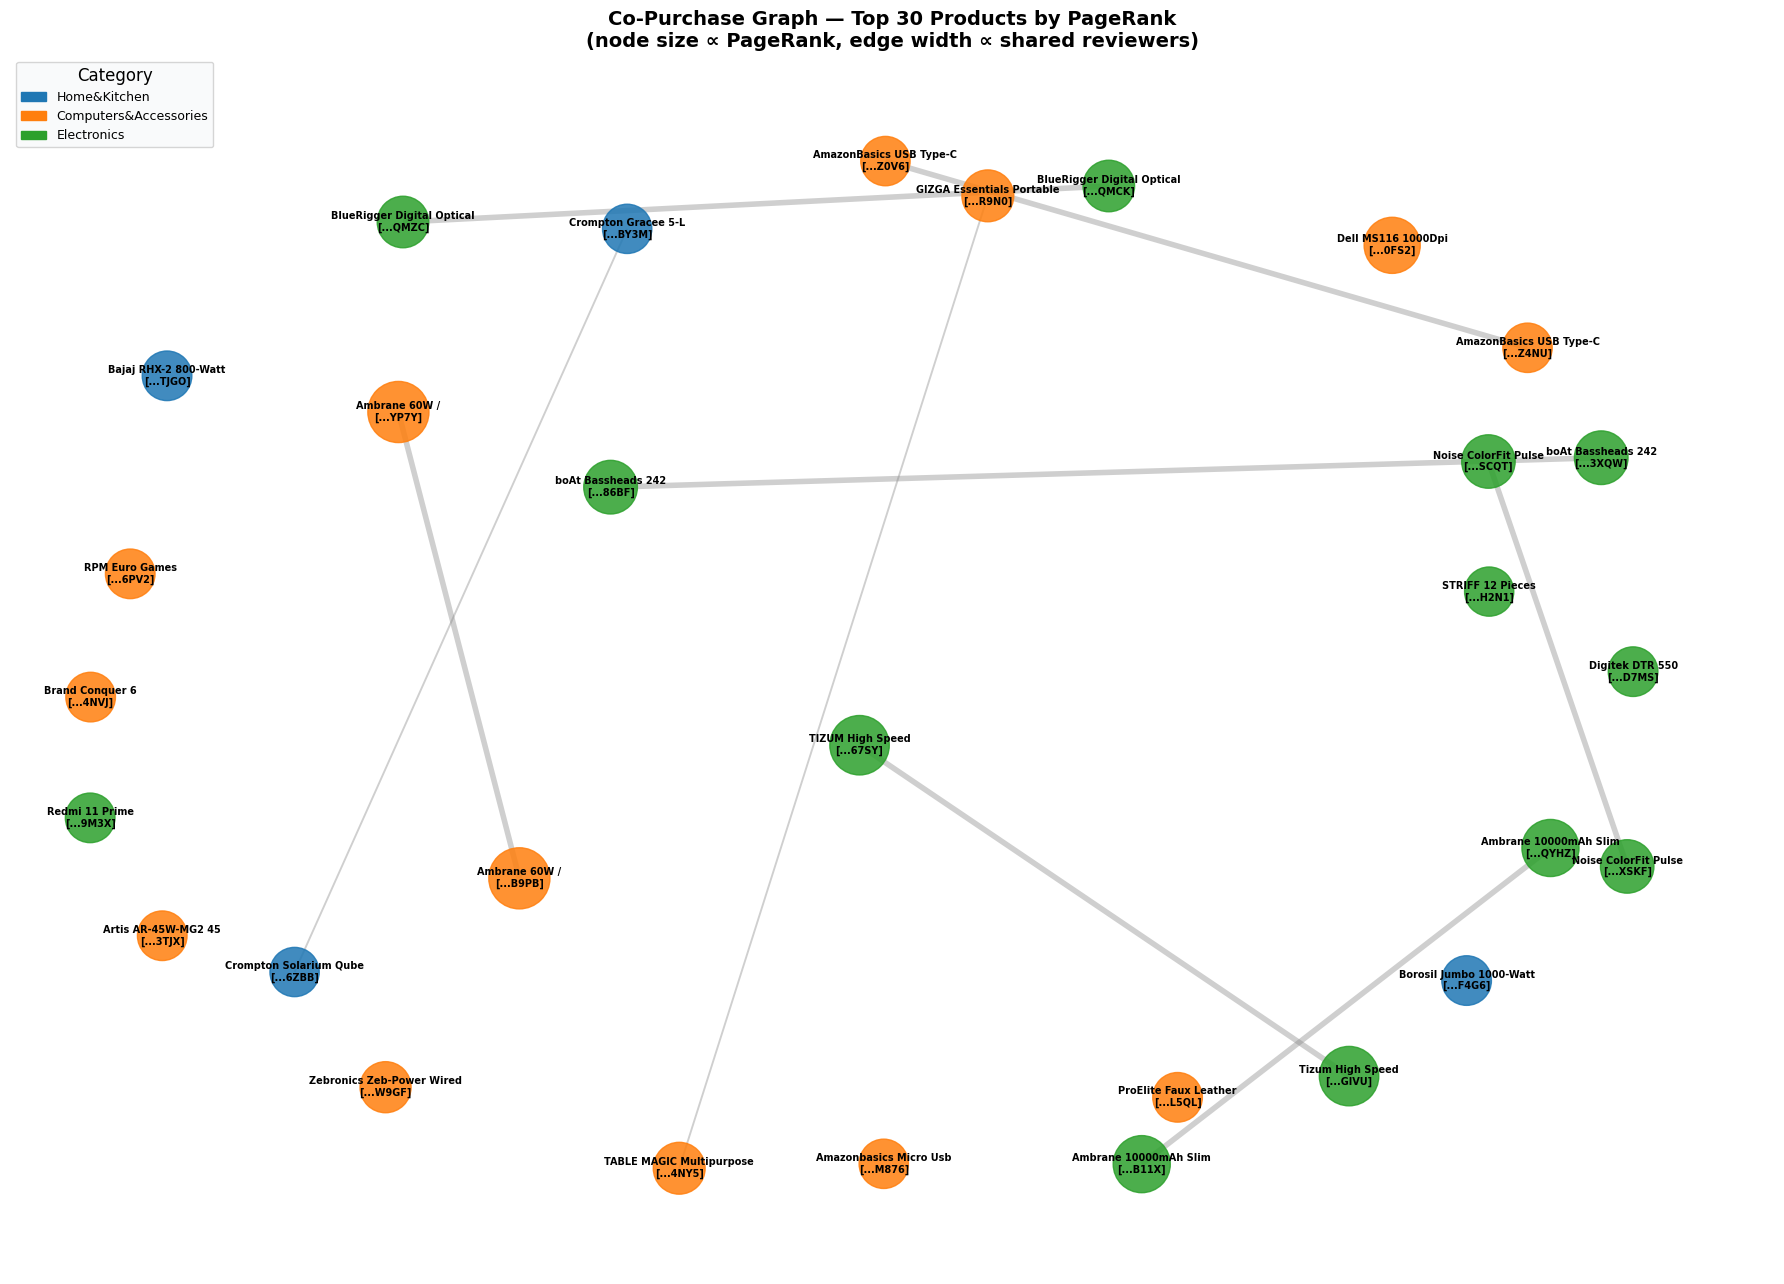

In [16]:
top30_ids = pagerank_df.head(30)['product_id'].tolist()
subG = G.subgraph(top30_ids).copy()

pr_vals  = {n: pagerank_scores.get(n, 0) for n in subG.nodes()}
node_size = [pr_vals[n] * 500000 for n in subG.nodes()]

node_cats = {row['product_id']: row['main_category'] for _, row in df_graph.iterrows()}
all_cats = list(set(node_cats.get(n, 'Unknown') for n in subG.nodes()))
cat_color_map = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(all_cats)}
node_colors = [cat_color_map.get(node_cats.get(n, 'Unknown'), 'gray') for n in subG.nodes()]

edge_weights = [subG[u][v].get('weight', 1) for u, v in subG.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [1 + 3 * (w / max_w) for w in edge_weights]

def make_label(pid, name):
    words = str(name).split()
    short_name = ' '.join(words[:3])
    pid_suffix = str(pid)[-4:]
    return f'{short_name}\n[...{pid_suffix}]'

name_map = {row['product_id']: make_label(row['product_id'], row['product_name'])
            for _, row in df_graph.iterrows()}
labels = {n: name_map.get(n, n[:10]) for n in subG.nodes()}

plt.figure(figsize=(18, 13))
pos = nx.spring_layout(subG, k=2.5, seed=42)

nx.draw_networkx_nodes(subG, pos, node_size=node_size, node_color=node_colors, alpha=0.85)
nx.draw_networkx_edges(subG, pos, width=edge_widths, alpha=0.4, edge_color='#888888')
nx.draw_networkx_labels(subG, pos, labels=labels, font_size=7, font_weight='bold')

legend_patches = [mpatches.Patch(color=cat_color_map[c], label=c) for c in all_cats]
plt.legend(handles=legend_patches, loc='upper left', fontsize=9, title='Category')
plt.title('Co-Purchase Graph — Top 30 Products by PageRank\n(node size ∝ PageRank, edge width ∝ shared reviewers)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()
